In [2]:
from pymongo import MongoClient
import warnings

warnings.filterwarnings("ignore")
from datetime import datetime
import pandas as pd
import json
client = MongoClient("mongodb://localhost:27017/")
db = client["StackOverFlow"]
collections=db['allquestions_with_allanswers']
def load_data_from_mongo(mongo_uri: str, db_name: str, collection_name: str) -> pd.DataFrame:
    client = MongoClient(mongo_uri)
    db     = client[db_name]
 
    query = {
        "is_answered":  True,
        "answer_count": {"$gte": 1},
        "score":        {"$gte": 1},
        "tags":         {"$exists": True, "$ne": []},
        "view_count":   {"$gte":1}
    }
 
    projection = {
        "_id":     0,
        "question_id":  1,
        "title":        1,
        "tags":         1,
        "score":        1,
        "answer_count": 1,
        "body":1,
        "protected_date":1,
        "last_activity_date":1,
        "creation_date":1,
        "last_edit_date":1,
        "content_license":1,
        "AllAnswers":1
    }
 
    cursor = db[collection_name].find(query, projection)
    df     = pd.DataFrame(list(cursor))
 
    print(f"Loaded {len(df)} questions from MongoDB")
    return df

data=load_data_from_mongo("mongodb://localhost:27017/","StackOverFlow","allquestions_with_allanswers")


Loaded 3006 questions from MongoDB


In [3]:
data

,tags,protected_date,answer_count,score,last_activity_date,creation_date,last_edit_date,question_id,content_license,title,body,AllAnswers
0,"[android, android-studio, kotlin]",1.632592e+09,55,190,1721546303,1589490945,1.589496e+09,61807520,CC BY-SA 4.0,How to fix ERROR: No signature of method: buil...,<p>ERROR: No signature of method: build_ap86oa...,"[{'_id': 69c530e7ce4825bba74fab32, 'owner': {'..."
1,"[android, google-play, android-manifest, googl...",NaN,7,190,1769683444,1658868456,1.721867e+09,73129574,CC BY-SA 4.0,You can&#39;t submit updates as some informati...,<p>I cannot update my app in Google Play since...,"[{'_id': 69c530e7ce4825bba74fab50, 'owner': {'..."
2,"[mysql, svn]",NaN,15,189,1733286943,1218228602,1.318946e+09,6371,CC BY-SA 3.0,"How do you manage databases in development, te...",<p>I've had a hard time trying to find good ex...,"[{'_id': 69c530e7ce4825bba74fab57, 'owner': {'..."
3,"[linq, linq-to-sql, linq-to-entities, linq-to-...",NaN,9,189,1538736603,1219157443,1.592644e+09,16322,NaN,Learning about LINQ,<h2>Overview</h2>\n<p>One of the things I've a...,"[{'_id': 69c530e7ce4825bba74fab66, 'owner': {'..."
4,"[java, exception, return, try-catch-finally]",NaN,6,189,1704360229,1220757358,1.578251e+09,48088,CC BY-SA 4.0,Returning from a finally block in Java,<p>I was surprised recently to find that it's ...,"[{'_id': 69c530e7ce4825bba74fab6f, 'owner': {'..."
...,...,...,...,...,...,...,...,...,...,...,...,...
3001,"[c++, vector, iterator]",NaN,13,174,1770456730,1283270911,1.638433e+09,3610933,CC BY-SA 4.0,Iterating C++ vector from the end to the begin...,<p>Is it possible to iterate a vector from the...,"[{'_id': 69c530ebce4825bba7505173, 'owner': {'..."
3002,"[docker, dockerfile]",NaN,8,109,1770456703,1493997564,NaN,43808558,CC BY-SA 3.0,Docker command/option to display or list the b...,<p>Is there a command/option to display or lis...,"[{'_id': 69c530ebce4825bba7505180, 'owner': {'..."
3003,"[t-sql, sql-server-2012]",NaN,5,4,1770455970,1384831493,1.770456e+09,20062544,CC BY-SA 4.0,Get first and last day of any year,<p>I'm trying to get the first and last day of...,"[{'_id': 69c530ebce4825bba7505188, 'owner': {'..."
3004,"[c, c-preprocessor]",NaN,8,19,1770454375,1337853136,1.479226e+09,10735099,CC BY-SA 3.0,Why does #define not require a semicolon?,<p>I was writing some test code in <strong>C</...,"[{'_id': 69c530ebce4825bba750518d, 'owner': {'..."


In [4]:
data.drop(columns=["last_activity_date","last_edit_date","protected_date","content_license"],inplace=True)

In [5]:
data.head()

,tags,answer_count,score,creation_date,question_id,title,body,AllAnswers
0,"[android, android-studio, kotlin]",55,190,1589490945,61807520,How to fix ERROR: No signature of method: buil...,<p>ERROR: No signature of method: build_ap86oa...,"[{'_id': 69c530e7ce4825bba74fab32, 'owner': {'..."
1,"[android, google-play, android-manifest, googl...",7,190,1658868456,73129574,You can&#39;t submit updates as some informati...,<p>I cannot update my app in Google Play since...,"[{'_id': 69c530e7ce4825bba74fab50, 'owner': {'..."
2,"[mysql, svn]",15,189,1218228602,6371,"How do you manage databases in development, te...",<p>I've had a hard time trying to find good ex...,"[{'_id': 69c530e7ce4825bba74fab57, 'owner': {'..."
3,"[linq, linq-to-sql, linq-to-entities, linq-to-...",9,189,1219157443,16322,Learning about LINQ,<h2>Overview</h2>\n<p>One of the things I've a...,"[{'_id': 69c530e7ce4825bba74fab66, 'owner': {'..."
4,"[java, exception, return, try-catch-finally]",6,189,1220757358,48088,Returning from a finally block in Java,<p>I was surprised recently to find that it's ...,"[{'_id': 69c530e7ce4825bba74fab6f, 'owner': {'..."


In [6]:
data['creation_date']=data['creation_date'].apply(lambda x: pd.to_datetime(x))

In [7]:
def convert_list_to_str(text:str):
    clean_text=text.replace("[","").replace("]","").replace(","," and").strip().lower()
    return "and the Tags: "+clean_text

convert_list_to_str("[android, android-studio, kotlin]")
data['Text_Tags']=data['tags'].apply(lambda x: convert_list_to_str(str(x)))


In [8]:
data['All_Text']=data['title']+" "+data['body']+" "+data['Text_Tags']

In [9]:
from bs4 import BeautifulSoup
import re

def clean_text(text: str) -> str:
    if not isinstance(text, str):
        return ""

    # Remove HTML while preserving spacing
    text = BeautifulSoup(text, "lxml").get_text(separator=" ")

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text
data['All_Text']=data['All_Text'].apply(lambda x: clean_text(x))

In [10]:
from sentence_transformers import SentenceTransformer
documents=data['All_Text'].values
model = SentenceTransformer("BAAI/bge-base-en-v1.5")

embeddings = model.encode(
    documents,
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

embeddings

Batches:   0%|          | 0/47 [00:00<?, ?it/s]

array([[ 0.0019675 ,  0.01905814,  0.00923447, ...,  0.05520245,
        -0.00337278, -0.00583925],
       [-0.01613902, -0.00844279,  0.03105339, ..., -0.00801307,
        -0.02221222,  0.01944003],
       [ 0.00460343,  0.01916396, -0.00802197, ..., -0.02155492,
         0.02280164, -0.01140087],
       ...,
       [-0.05385671,  0.01878489,  0.02762314, ...,  0.02622784,
         0.0134943 , -0.00617543],
       [-0.03953166,  0.01448836, -0.02978491, ..., -0.01294697,
        -0.00531051,  0.04488607],
       [-0.01463607, -0.02907276,  0.02579882, ...,  0.00100982,
        -0.00942435,  0.01872914]], dtype=float32)

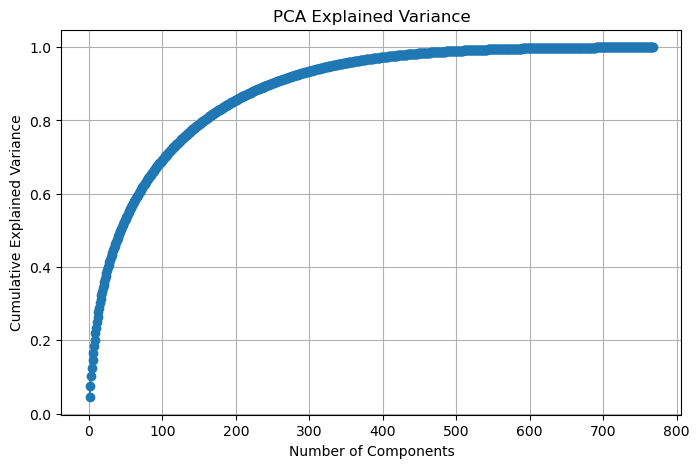

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

pca = PCA()
pca.fit(embeddings)

cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(cumulative_variance)+1), cumulative_variance, marker='o')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA Explained Variance")
plt.grid(True)
plt.show()

In [12]:
import umap

umap_model = umap.UMAP(
    n_neighbors=15,
    n_components=500,
    min_dist=0.0,
    metric="cosine",
    random_state=42
)

reduced_embeddings = umap_model.fit_transform(embeddings)

In [13]:
import numpy as np
import hdbscan
from sklearn.metrics import silhouette_score

silhouette_scores = {}

random_samples = np.random.choice([1, 2, 3, 4, 5, 8], size=35)

for min_cluster_size, min_samples in zip(range(5, 40), random_samples):

    cluster_model = hdbscan.HDBSCAN(
        min_cluster_size=min_cluster_size,
        min_samples=min_samples,
        metric="euclidean",
        cluster_selection_method="eom",
        prediction_data=True
    )

    labels = cluster_model.fit_predict(reduced_embeddings)

    mask = labels != -1

    if len(np.unique(labels[mask])) < 2:
        continue

    score = silhouette_score(
        reduced_embeddings[mask],
        labels[mask],
        metric="euclidean"
    )

    silhouette_scores[score] = [min_cluster_size, min_samples]

print(max(silhouette_scores.items()))

(0.5846483707427979, [15, 8])


In [14]:
import hdbscan
cluster_model = hdbscan.HDBSCAN(
    min_cluster_size=15,
    min_samples=8,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

labels=cluster_model.fit_predict(reduced_embeddings)

labels

array([16, 16,  1, ...,  2, -1, 14], dtype=int64)

In [15]:
data['cluster']=labels
data['embedding']=list(reduced_embeddings)

In [19]:
data.to_csv(r"D:\my projects\FixFlow-\notebooks\data.csv", index=False)